In [16]:
from chipanalysis.utils.file_reader import *
from chipanalysis.utils.maye_video_axio  import *

from pathlib import Path
from aicspylibczi import CziFile
import matplotlib.pyplot as plt
import numpy as np
from chipanalysis.utils.ROI_selector import ROI_selector, ROI_selector_down
from chipanalysis.chip_alignment import align_chip_to_image,get_roi_from_result

from PIL import Image

%load_ext autoreload
%autoreload 2

%matplotlib widget

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [3]:
root_path = "/Users/bisot/Documents/PostDoc2/test_data"
fig_path = "/Users/bisot/Documents/PostDoc2/test_data"

czi_name = "CB27-01.czi"

czi_path = Path(root_path,czi_name)
czi = CziFile(czi_path)

dims = czi.dims
sizes = czi.size

dim_sizes = dict(zip(dims, sizes))
dim_sizes["T"]
pixel_size = get_pixel_sizes_um(czi)
times = get_timestamps_by_T(czi, C=0, Z=0)


.//Scaling//Distance[@Id='X']//Value
.//Scaling//Distance[@Id='Y']//Value


In [4]:
channel = 2
time = 0
img, img_disp = get_frame(czi,time,channel)

In [ ]:
result = align_chip_to_image(img, pixel_size_um=pixel_size["X"], debug=False)

In [9]:
def select_roi(img):
    roi, _ = get_roi_from_result(
    result,
    result['rotate_fn'](img) ,
    pad_left_um=-500.0,   # expand chip box leftward (µm)
    pad_right_um=-1000.0,  # expand chip box rightward (µm)
    pad_top_um=2000.0,    # pad above & below main channel centre (symmetric)
)
    return roi

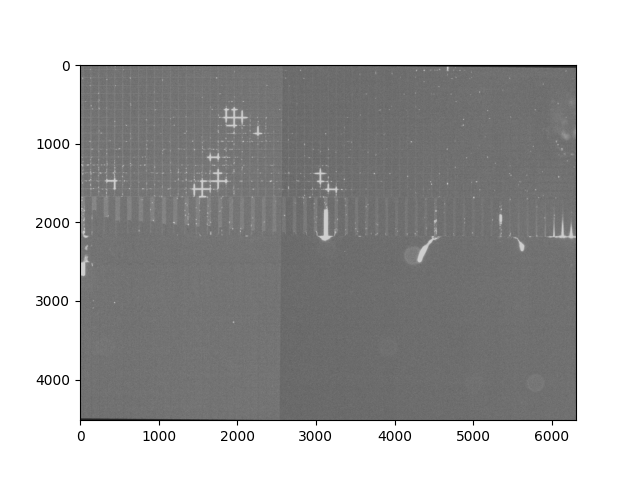

In [19]:
channel = 1
time = 20
img, img_disp = get_frame(czi,time,channel,gamma=1)
roi = select_roi(img_disp)
fig,ax = plt.subplots()
ax.imshow(roi,cmap="gray")

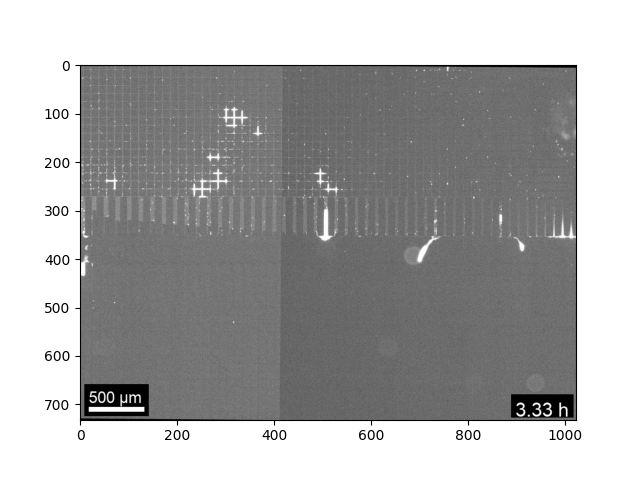

In [20]:
frame = make_annotated(
    roi,
    time,
    times,
    pixel_size["X"],
    resize_width= 1024,
    mode = "L"
)
fig,ax = plt.subplots()
ax.imshow(frame,cmap="gray")

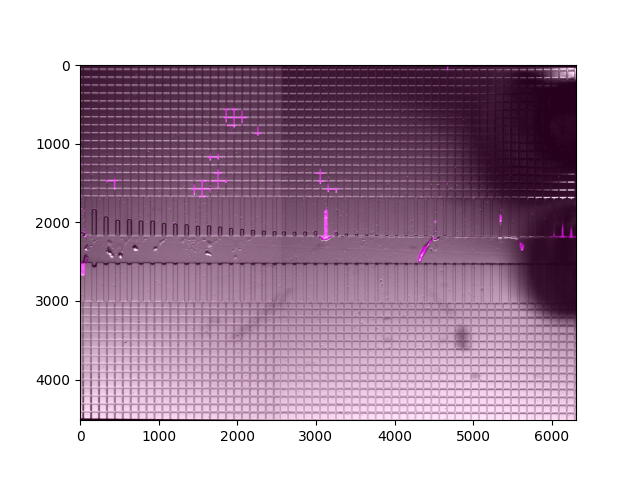

In [21]:
stretch_min = 96
stretch_max = 99.5
_, ch_magenta = get_frame(czi, time, 1,gamma=1, stretch_min = stretch_min, stretch_max = stretch_max)
_, ch_gray    = get_frame(czi, time, 2, gamma=1, )
ch_magenta = select_roi(ch_magenta)
ch_gray = select_roi(ch_gray)

ch_magenta = norm(ch_magenta)
ch_gray    = norm(ch_gray)

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
merged      = np.clip(rgb_magenta + rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

In [26]:
#select contrasts
time = 0
ch_magenta, _ = get_frame(czi, time, 1)
ch_gray, _     = get_frame(czi, time, 2)
ch_green, _= get_frame(czi, time, 0)

ch_magenta = select_roi(ch_magenta)
ch_gray = select_roi(ch_gray)
ch_green = select_roi(ch_green)

stretch_min = 90
stretch_max = 99.5
lo_magenta, hi_magenta = np.percentile(ch_magenta, (stretch_min, stretch_max))
stretch_min = 90
stretch_max = 99.5
lo_green, hi_green = np.percentile(ch_green, (stretch_min, stretch_max))

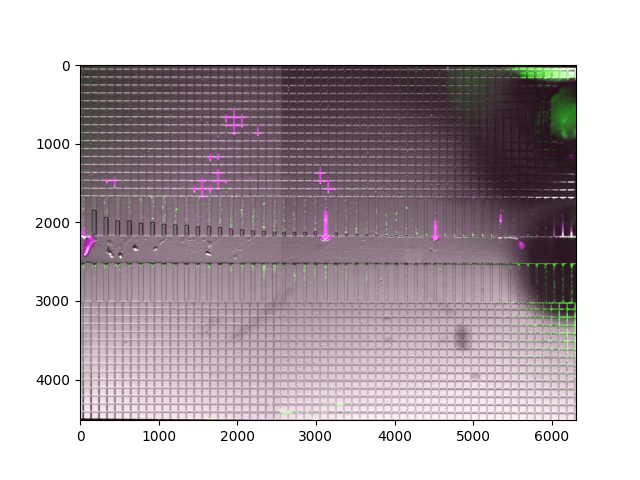

In [27]:

time = 10

_, ch_magenta = get_frame(czi, time, 1,gamma=0.45,lo=lo_magenta,hi=hi_magenta)
_, ch_gray    = get_frame(czi, time, 2, gamma=1)
_, ch_green= get_frame(czi, time, 0,gamma=0.45, lo=lo_green,hi=hi_green)

ch_magenta = select_roi(ch_magenta)
ch_gray = select_roi(ch_gray)
ch_green = select_roi(ch_green)
ch_magenta = norm(ch_magenta)
ch_gray    = norm(ch_gray)
ch_green = norm(ch_green)

rgb_magenta = mcherry(ch_magenta)[..., :3]
rgb_gray    = gray_cmap(ch_gray)[..., :3]
rgb_green = gfp(ch_green)[..., :3]

merged      = np.clip(rgb_magenta + rgb_green+rgb_gray, 0, 1)
fig,ax = plt.subplots()
ax.imshow(merged)

In [29]:
# ---- your settings ----
scale_factor = 6000.0   # 10x faster
fps = 10
output = "/Users/bisot/Documents/PostDoc2/test_data/movie.mp4"

# Parse timestamps
frame_idxs = [i for i, _ in times]
ts = [s for _, s in times]

# Compute real deltas (seconds)
real_deltas = [None]
for k in range(1, len(ts)):
    dt = max((ts[k] - ts[k-1]).total_seconds(), 0.0)
    real_deltas.append(dt)

positive = [d for d in real_deltas[1:] if d and d > 0]
baseline = median(positive) if positive else 1.0
real_deltas[0] = baseline
if len(real_deltas) > 1:
    real_deltas[-1] = real_deltas[-2] if real_deltas[-2] is not None else baseline

video_durations = [clamp(float(d) / scale_factor, 0.0, 1e12) for d in real_deltas]

# Build clips
clips = []
for (frame_i, (time_i, _)), dur in zip(enumerate(times[:5]), video_durations[:5]):
    # NOTE: you currently loop "for time,_ in times:" where time is frame index.
    time = time_i

    _, ch_magenta = get_frame(czi, time, 1,gamma=0.45,lo=lo_magenta,hi=hi_magenta)
    _, ch_gray    = get_frame(czi, time, 2, gamma=1)
    _, ch_green= get_frame(czi, time, 0,gamma=0.45, lo=lo_green,hi=hi_green)

    ch_magenta = select_roi(ch_magenta)
    ch_gray = select_roi(ch_gray)
    ch_green = select_roi(ch_green)
    ch_magenta = norm(ch_magenta)
    ch_gray    = norm(ch_gray)
    ch_green = norm(ch_green)

    rgb_magenta = mcherry(ch_magenta)[..., :3]
    rgb_gray    = gray_cmap(ch_gray)[..., :3]
    rgb_green = gfp(ch_green)[..., :3]

    merged      = np.clip(rgb_magenta + rgb_green+rgb_gray, 0, 1)

    frame = make_annotated(
        merged,
        time,
        times,          # pass indices (or your original list, up to you)
        pixel_size["X"],
        resize_width=1024,
        mode="RGB",
    )

    # Ensure uint8 for MoviePy
    if frame.dtype != np.uint8:
        frame_u8 = (np.clip(frame, 0, 1) * 255).astype(np.uint8) if frame.max() <= 1.0 else frame.astype(np.uint8)
    else:
        frame_u8 = frame

    clips.append(ImageClip(frame_u8, duration=dur))

final = concatenate_videoclips(clips, method="compose")
final.write_videofile(
    output,
    fps=fps,
    codec="libx264",
    audio=False,
    ffmpeg_params=[
        "-pix_fmt", "yuv420p",
        "-movflags", "+faststart",
        "-profile:v", "baseline",
        "-vf", "scale=trunc(iw/2)*2:trunc(ih/2)*2",
    ],
)

print("✅ Done:", output)


MoviePy - Building video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4.
MoviePy - Writing video /Users/bisot/Documents/PostDoc2/test_data/movie.mp4



MoviePy - Done !
MoviePy - video ready /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
✅ Done: /Users/bisot/Documents/PostDoc2/test_data/movie.mp4
